In [6]:
# automatically reload each function when called for development
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# Import the PNGmodel class
from codes.PNGmodel import PNGmodel
from codes.MathModels import Y1
from codes.helper_functions import *
from cosmoprimo import *
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# Make Fiducial Case

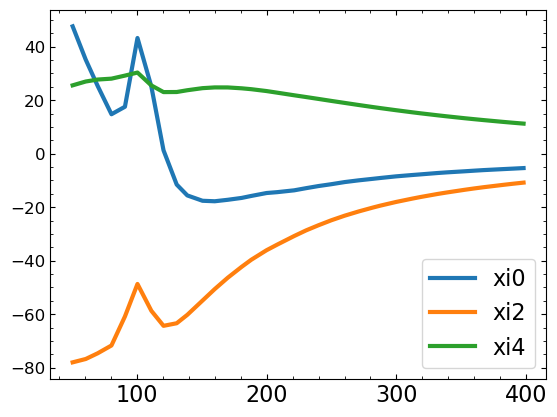

In [8]:
cosmo = fiducial.Planck2018FullFlatLCDM()
z_fid = 0.75

fo = Fourier(cosmo, engine='class')
pk = fo.pk_interpolator()
pk1d = pk.to_1d(z=z_fid)
# k = np.geomspace(pk1d.extrap_kmin, pk1d.extrap_kmax, 1024)
k = np.geomspace(pk1d.extrap_kmin, pk1d.extrap_kmax, 1024)
s, xi0 = PowerToCorrelation(k, ell=0)(pk1d(k))
s, xi2 = PowerToCorrelation(k, ell=2)(pk1d(k))
s, xi4 = PowerToCorrelation(k, ell=4)(pk1d(k))

s_values = np.linspace(50, 400, 36)
idxs = []
for sval in s_values:
    idxs.append(min(range(len(s)), key=lambda i: abs(s[i]-sval)))
s_out = s[idxs]

bfid = 2.0
Om_m0_fid = cosmo['Omega_m']
f_fid = Omega_m_z(z_fid,Om_m0_fid)**0.55

xi0_out = (bfid**2 + (2/3)*bfid*f_fid + (f_fid**2)/5)*xi0[idxs]
xi2_out = ((4/3)*bfid*f_fid + (4/7)*(f_fid**2))*xi2[idxs]
xi4_out = (f_fid**2)*xi4[idxs]
fid = Table(data = [s_out, xi0_out, xi2_out, xi4_out],
            names = ['s','xi0','xi2','xi4'])

for xi in ['xi0','xi2','xi4']:
    plt.plot(fid['s'], fid['s']**2 *fid[xi], label=xi)
plt.legend()

fid.write('./inputs/fiducial.fits', format='fits', overwrite=True)

# Make Observation

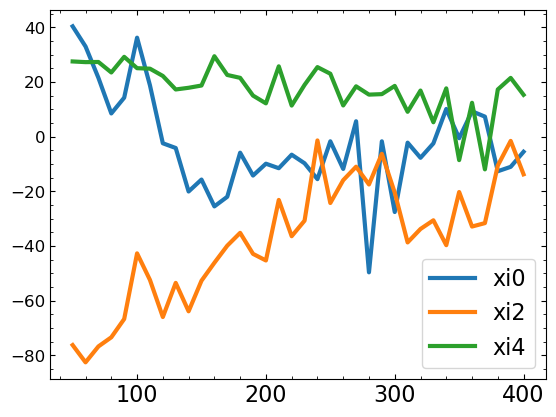

In [81]:
cosmo = fiducial.DESI()
z_eff = 0.78

fo = Fourier(cosmo, engine='class')
pk = fo.pk_interpolator()
pk1d = pk.to_1d(z=z_eff)
# k = np.geomspace(pk1d.extrap_kmin, pk1d.extrap_kmax, 1024)
k = np.geomspace(pk1d.extrap_kmin, pk1d.extrap_kmax, 2**20)
s, xi0 = PowerToCorrelation(k, ell=0)(pk1d(k))
s, xi2 = PowerToCorrelation(k, ell=2)(pk1d(k))
s, xi4 = PowerToCorrelation(k, ell=4)(pk1d(k))

s_values = np.linspace(50, 400, 36)
idxs = []
for sval in s_values:
    idxs.append(min(range(len(s)), key=lambda i: abs(s[i]-sval)))
s_out = s[idxs]

b = 1.95
Om_m0 = cosmo['Omega_m']
f = Omega_m_z(z_eff,Om_m0)**0.55

alpha = -2
beta = 4
xi0_out = (b**2 + (2/3)*b*f + (f**2)/5)*xi0[idxs] + np.random.randn(len(s_out))*(1/(s_out))*(beta * 10**(alpha))
xi2_out = ((4/3)*b*f + (4/7)*(f**2))*xi2[idxs] + np.random.randn(len(s_out))*(1/(s_out))*(beta * 10**(alpha))
xi4_out = (f**2)*xi4[idxs] + np.random.randn(len(s_out))*(1/(s_out))*(beta * 10**(alpha))

obs = Table(data = [s_out, xi0_out, xi2_out, xi4_out],
            names = ['s','xi0','xi2','xi4'])

for xi in ['xi0','xi2','xi4']:
    plt.plot(obs['s'], obs['s']**2 *obs[xi], label=xi)
plt.legend()

obs.write('./inputs/observation.fits', format='fits', overwrite=True)

# Make Covariance Matrix

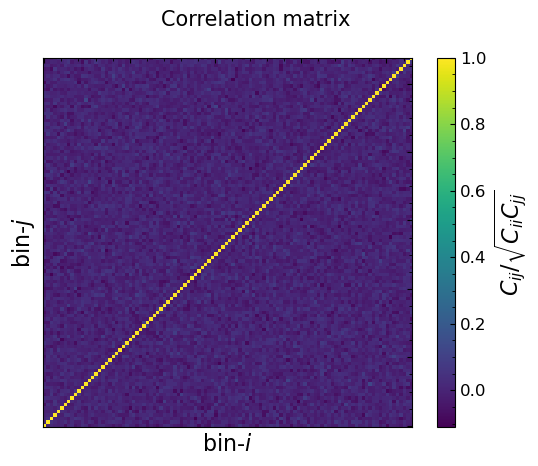

In [79]:
# theory
cosmo = fiducial.DESI()
z_eff = 0.78

fo = Fourier(cosmo, engine='class')
pk = fo.pk_interpolator()
pk1d = pk.to_1d(z=z_eff)
# k = np.geomspace(pk1d.extrap_kmin, pk1d.extrap_kmax, 1024)
k = np.geomspace(pk1d.extrap_kmin, pk1d.extrap_kmax, 2**20)
s, xi0 = PowerToCorrelation(k, ell=0)(pk1d(k))
s, xi2 = PowerToCorrelation(k, ell=2)(pk1d(k))
s, xi4 = PowerToCorrelation(k, ell=4)(pk1d(k))

s_values = np.linspace(50, 400, 36)
idxs = []
for sval in s_values:
    idxs.append(min(range(len(s)), key=lambda i: abs(s[i]-sval)))
s_out = s[idxs]

b = 1.95
Om_m0 = cosmo['Omega_m']
f = Omega_m_z(z_eff,Om_m0)**0.55

alpha = -2
beta = 4
noisy_obs = []
for i in range(1000):
    noisy = np.concatenate([(b**2 + (2/3)*b*f + (f**2)/5)*xi0[idxs] + np.random.randn(len(s_out))*(1/(s_out))*(beta*10**(alpha)),
                            ((4/3)*b*f + (4/7)*(f**2))*xi2[idxs] + np.random.randn(len(s_out))*(1/(s_out))*(beta*10**(alpha)),
                            (f**2)*xi4[idxs] + np.random.randn(len(s_out))*(1/(s_out))*(beta*10**(alpha))])
    noisy_obs.append(noisy)

noisy_obs = np.asarray(noisy_obs)

cov = np.cov(noisy_obs.T)
corr = np.corrcoef(noisy_obs.T)

plt.imshow(corr, origin='lower')
plt.colorbar(label=r'$C_{ij}/\sqrt{C_{ii}C_{jj}}$')
plt.suptitle(r'Correlation matrix', fontsize=15)
plt.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
plt.xlabel(r'bin-$i$')
plt.ylabel(r'bin-$j$')
plt.show()

np.save('./inputs/covariance_matrix.npy', cov)

# Quadratic Fits

### PNG Fits

In [94]:
df0 = pd.DataFrame(columns=['term', 's', 'c1', 'c2'])
df0['term'] = len(s_out)*['xi0']
df0['s'] = s_values
df0['c1'] = np.concatenate([np.random.uniform(0,1,7)*10**(-4),np.random.uniform(0,1,18)*10**(-5), np.random.uniform(0,1,11)*10**(-6)])
df0['c2'] = np.concatenate([np.random.normal(0,1,18)*10**(-8),np.random.uniform(0,1,18)*10**(-7)])

df2 = pd.DataFrame(columns=['term', 's', 'c1', 'c2'])
df2['term'] = len(s_out)*['xi2']
df2['s'] = s_values
df2['c1'] = np.random.normal(0,1,36)*10**(-6)
df2['c2'] = np.zeros(36)

df4 = pd.DataFrame(columns=['term', 's', 'c1', 'c2'])
df4['term'] = len(s_out)*['xi4']
df4['s'] = s_values
df4['c1'] = np.zeros(36)
df4['c2'] = np.zeros(36)

df = pd.concat([df0,df2,df4])
df = df.reset_index(drop=True)
df = df[['term', 's', 'c1', 'c2']]
df.to_csv('./inputs/quadfits_PNG.csv', index=False)

### Ksys fits

In [98]:
regions = ['SGC', 'MZLS', 'DEC']

for reg in regions:
    df_temp = df.copy()
    df_temp['c1'] = np.concatenate([np.random.uniform(0,1,int(len(df_temp)/2))*10**(-5),np.random.uniform(0,1,int(len(df_temp)/2))*10**(-6)])
    df_temp['c2'] = np.concatenate([np.random.uniform(0,1,int(len(df_temp)/2))*10**(-8),np.random.uniform(0,1,int(len(df_temp)/2))*10**(-9)])
    df_temp.to_csv(f'./inputs/quadfits_Ksys{reg}.csv', index=False)